# EfficientNet B2 Fine-Tuning: K-Fold Cross Validation & Holdout Test Set

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahmoudshaheen1134/plant-leaf-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plant-leaf-image-dataset' dataset.
Path to dataset files: /kaggle/input/plant-leaf-image-dataset


In [11]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from transformers import EfficientNetModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [12]:
# Hyperparameters
# Use the path variable from the kagglehub download in the previous cell
DATA_DIR = path
BATCH_SIZE = 32
NUM_EPOCHS = 10
K_FOLDS = 5
TEST_SIZE = 0.1  # 10% of data held out for final testing
LEARNING_RATE = 1e-3
WARMUP_STEPS = 50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

if os.path.exists(DATA_DIR):
    NUM_CLASSES = len([name for name in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, name))])
    NUM_CLASSES = max(NUM_CLASSES, 2)
else:
    NUM_CLASSES = 2
print(f"Number of classes: {NUM_CLASSES}")

Using device: cuda
Number of classes: 2


## Data Augmentation and Preprocessing

In [13]:
# Transforms (Methodology from the ashan branch)
train_transforms = transforms.Compose([
    transforms.Resize((288, 288)),
    transforms.RandomRotation(degrees=25),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.8, 1.2), shear=5.7),
    transforms.ColorJitter(brightness=(0.8, 1.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((288, 288)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class MapDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.indices)


## Data Splitting (Holdout Test Set & K-Fold Prep)

In [14]:
try:
    base_dataset = datasets.ImageFolder(root=DATA_DIR)
    targets = base_dataset.targets
    indices = np.arange(len(base_dataset))

    # 1. Hold out an untouched test dataset slice
    train_val_idx, test_idx, train_val_targets, test_targets = train_test_split(
        indices, targets, test_size=TEST_SIZE, stratify=targets, random_state=42
    )

    test_dataset = MapDataset(base_dataset, test_idx, transform=eval_transforms)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Total images: {len(base_dataset)}")
    print(f"Images reserved for Train/Val (K-Fold): {len(train_val_idx)}")
    print(f"Images reserved for Untouched Test Set: {len(test_dataset)}")

except Exception as e:
    print(f"Error loading dataset from {DATA_DIR}: {e}")
    train_val_idx, train_val_targets = [], []
    test_loader = []


Total images: 3588
Images reserved for Train/Val (K-Fold): 3229
Images reserved for Untouched Test Set: 359


## Model Definition (Backbone -> GAP -> 5 Parallel Dropouts -> Shared Dense -> Average)

In [15]:
class CustomEfficientNetB2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = EfficientNetModel.from_pretrained("google/efficientnet-b2")
        hidden_size = self.backbone.config.hidden_dim
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropouts = nn.ModuleList([nn.Dropout(p=0.5) for _ in range(5)])
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        x = outputs.last_hidden_state
        x = self.pool(x).flatten(1)
        logits = [self.classifier(dropout(x)) for dropout in self.dropouts]
        avg_logits = torch.stack(logits, dim=0).mean(dim=0)
        return avg_logits

def get_model_and_optimizer(num_classes, train_steps):
    model = CustomEfficientNetB2(num_classes=num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    # Initially freeze backbone
    for param in model.backbone.parameters():
        param.requires_grad = False

    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LEARNING_RATE)
    scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=train_steps)

    return model, criterion, optimizer, scheduler


## K-Fold Cross Validation Training Loop

In [16]:
def train_fold(fold, train_loader, val_loader, num_epochs):
    print(f"\n{'='*40}\nStarting Fold {fold}\n{'='*40}")

    total_steps = max(1, len(train_loader)) * num_epochs
    model, criterion, optimizer, scheduler = get_model_and_optimizer(NUM_CLASSES, total_steps)
    unfreeze_epoch = num_epochs // 2

    best_val_acc = 0.0
    best_model_state = None

    # History tracking
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        if epoch == unfreeze_epoch:
            print(f"  [Fold {fold} - Epoch {epoch+1}] Unfreezing backbone for fine-tuning")
            for param in model.backbone.parameters():
                param.requires_grad = True
            optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE / 10)
            remaining_epochs = num_epochs - unfreeze_epoch
            scheduler = get_cosine_schedule_with_warmup(
                optimizer, num_warmup_steps=0,
                num_training_steps=max(1, len(train_loader)) * remaining_epochs
            )

        model.train()
        total_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / max(1, total)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100. * val_correct / max(1, val_total)

        # Record history
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss/len(val_loader))
        history['val_acc'].append(val_acc)

        current_lr = scheduler.get_last_lr()[0]
        print(f"  Epoch [{epoch+1}/{num_epochs}] Train Loss: {history['train_loss'][-1]:.4f} Acc: {train_acc:.2f}% | Val Loss: {history['val_loss'][-1]:.4f} Acc: {val_acc:.2f}% | LR: {current_lr:.6f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

    print(f"Fold {fold} Best Val Acc: {best_val_acc:.2f}%")
    model.load_state_dict(best_model_state)
    return model, best_val_acc, history


Starting Fold 1


Loading weights:   0%|          | 0/506 [00:00<?, ?it/s]

[transformers] EfficientNetModel LOAD REPORT from: google/efficientnet-b2
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch [1/10] Train Loss: 0.1894 Acc: 96.09% | Val Loss: 0.1477 Acc: 97.99% | LR: 0.000996
  Epoch [2/10] Train Loss: 0.0165 Acc: 99.96% | Val Loss: 0.0693 Acc: 99.38% | LR: 0.000947
  Epoch [3/10] Train Loss: 0.0104 Acc: 99.96% | Val Loss: 0.0889 Acc: 98.30% | LR: 0.000849
  Epoch [4/10] Train Loss: 0.0089 Acc: 99.88% | Val Loss: 0.0542 Acc: 99.85% | LR: 0.000712
  Epoch [5/10] Train Loss: 0.0064 Acc: 100.00% | Val Loss: 0.0622 Acc: 99.38% | LR: 0.000552
  [Fold 1 - Epoch 6] Unfreezing backbone for fine-tuning
  Epoch [6/10] Train Loss: 0.0008 Acc: 100.00% | Val Loss: 0.0049 Acc: 100.00% | LR: 0.000090
  Epoch [7/10] Train Loss: 0.0001 Acc: 100.00% | Val Loss: 0.0023 Acc: 100.00% | LR: 0.000065
  Epoch [8/10] Train Loss: 0.0001 Acc: 100.00% | Val Loss: 0.0036 Acc: 100.00% | LR: 0.000035
  Epoch [9/10] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0011 Acc: 100.00% | LR: 0.000010
  Epoch [10/10] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0018 Acc: 100.00% | LR: 0.000000
Fold 1 Best

Loading weights:   0%|          | 0/506 [00:00<?, ?it/s]

...

[transformers] EfficientNetModel LOAD REPORT from: google/efficientnet-b2
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch [1/10] Train Loss: 0.2228 Acc: 89.97% | Val Loss: 0.1165 Acc: 98.14% | LR: 0.000996
  Epoch [2/10] Train Loss: 0.0191 Acc: 99.92% | Val Loss: 0.0709 Acc: 99.69% | LR: 0.000947
  Epoch [3/10] Train Loss: 0.0127 Acc: 99.92% | Val Loss: 0.0653 Acc: 98.92% | LR: 0.000849
  Epoch [4/10] Train Loss: 0.0086 Acc: 99.96% | Val Loss: 0.0534 Acc: 99.07% | LR: 0.000712
  Epoch [5/10] Train Loss: 0.0063 Acc: 100.00% | Val Loss: 0.0598 Acc: 99.07% | LR: 0.000552
  [Fold 4 - Epoch 6] Unfreezing backbone for fine-tuning
  Epoch [6/10] Train Loss: 0.0009 Acc: 100.00% | Val Loss: 0.0072 Acc: 99.85% | LR: 0.000090
  Epoch [7/10] Train Loss: 0.0001 Acc: 100.00% | Val Loss: 0.0023 Acc: 100.00% | LR: 0.000065
  Epoch [8/10] Train Loss: 0.0001 Acc: 100.00% | Val Loss: 0.0027 Acc: 100.00% | LR: 0.000035
  Epoch [9/10] Train Loss: 0.0001 Acc: 100.00% | Val Loss: 0.0017 Acc: 100.00% | LR: 0.000010
  Epoch [10/10] Train Loss: 0.0001 Acc: 100.00% | Val Loss: 0.0017 Acc: 100.00% | LR: 0.000000
Fold 4 Best 

Loading weights:   0%|          | 0/506 [00:00<?, ?it/s]

[transformers] EfficientNetModel LOAD REPORT from: google/efficientnet-b2
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch [1/10] Train Loss: 0.1917 Acc: 95.78% | Val Loss: 0.1357 Acc: 97.98% | LR: 0.000996
  Epoch [2/10] Train Loss: 0.0161 Acc: 100.00% | Val Loss: 0.0899 Acc: 99.07% | LR: 0.000947
  Epoch [3/10] Train Loss: 0.0101 Acc: 100.00% | Val Loss: 0.0899 Acc: 98.45% | LR: 0.000849
  Epoch [4/10] Train Loss: 0.0093 Acc: 99.88% | Val Loss: 0.0565 Acc: 98.60% | LR: 0.000712
  Epoch [5/10] Train Loss: 0.0064 Acc: 99.96% | Val Loss: 0.0683 Acc: 98.14% | LR: 0.000552
  [Fold 5 - Epoch 6] Unfreezing backbone for fine-tuning
  Epoch [6/10] Train Loss: 0.0007 Acc: 100.00% | Val Loss: 0.0012 Acc: 100.00% | LR: 0.000090
  Epoch [7/10] Train Loss: 0.0001 Acc: 100.00% | Val Loss: 0.0016 Acc: 100.00% | LR: 0.000065
  Epoch [8/10] Train Loss: 0.0001 Acc: 100.00% | Val Loss: 0.0009 Acc: 100.00% | LR: 0.000035
  Epoch [9/10] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0008 Acc: 100.00% | LR: 0.000010
  Epoch [10/10] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0012 Acc: 100.00% | LR: 0.000000
Fold 5 Bes

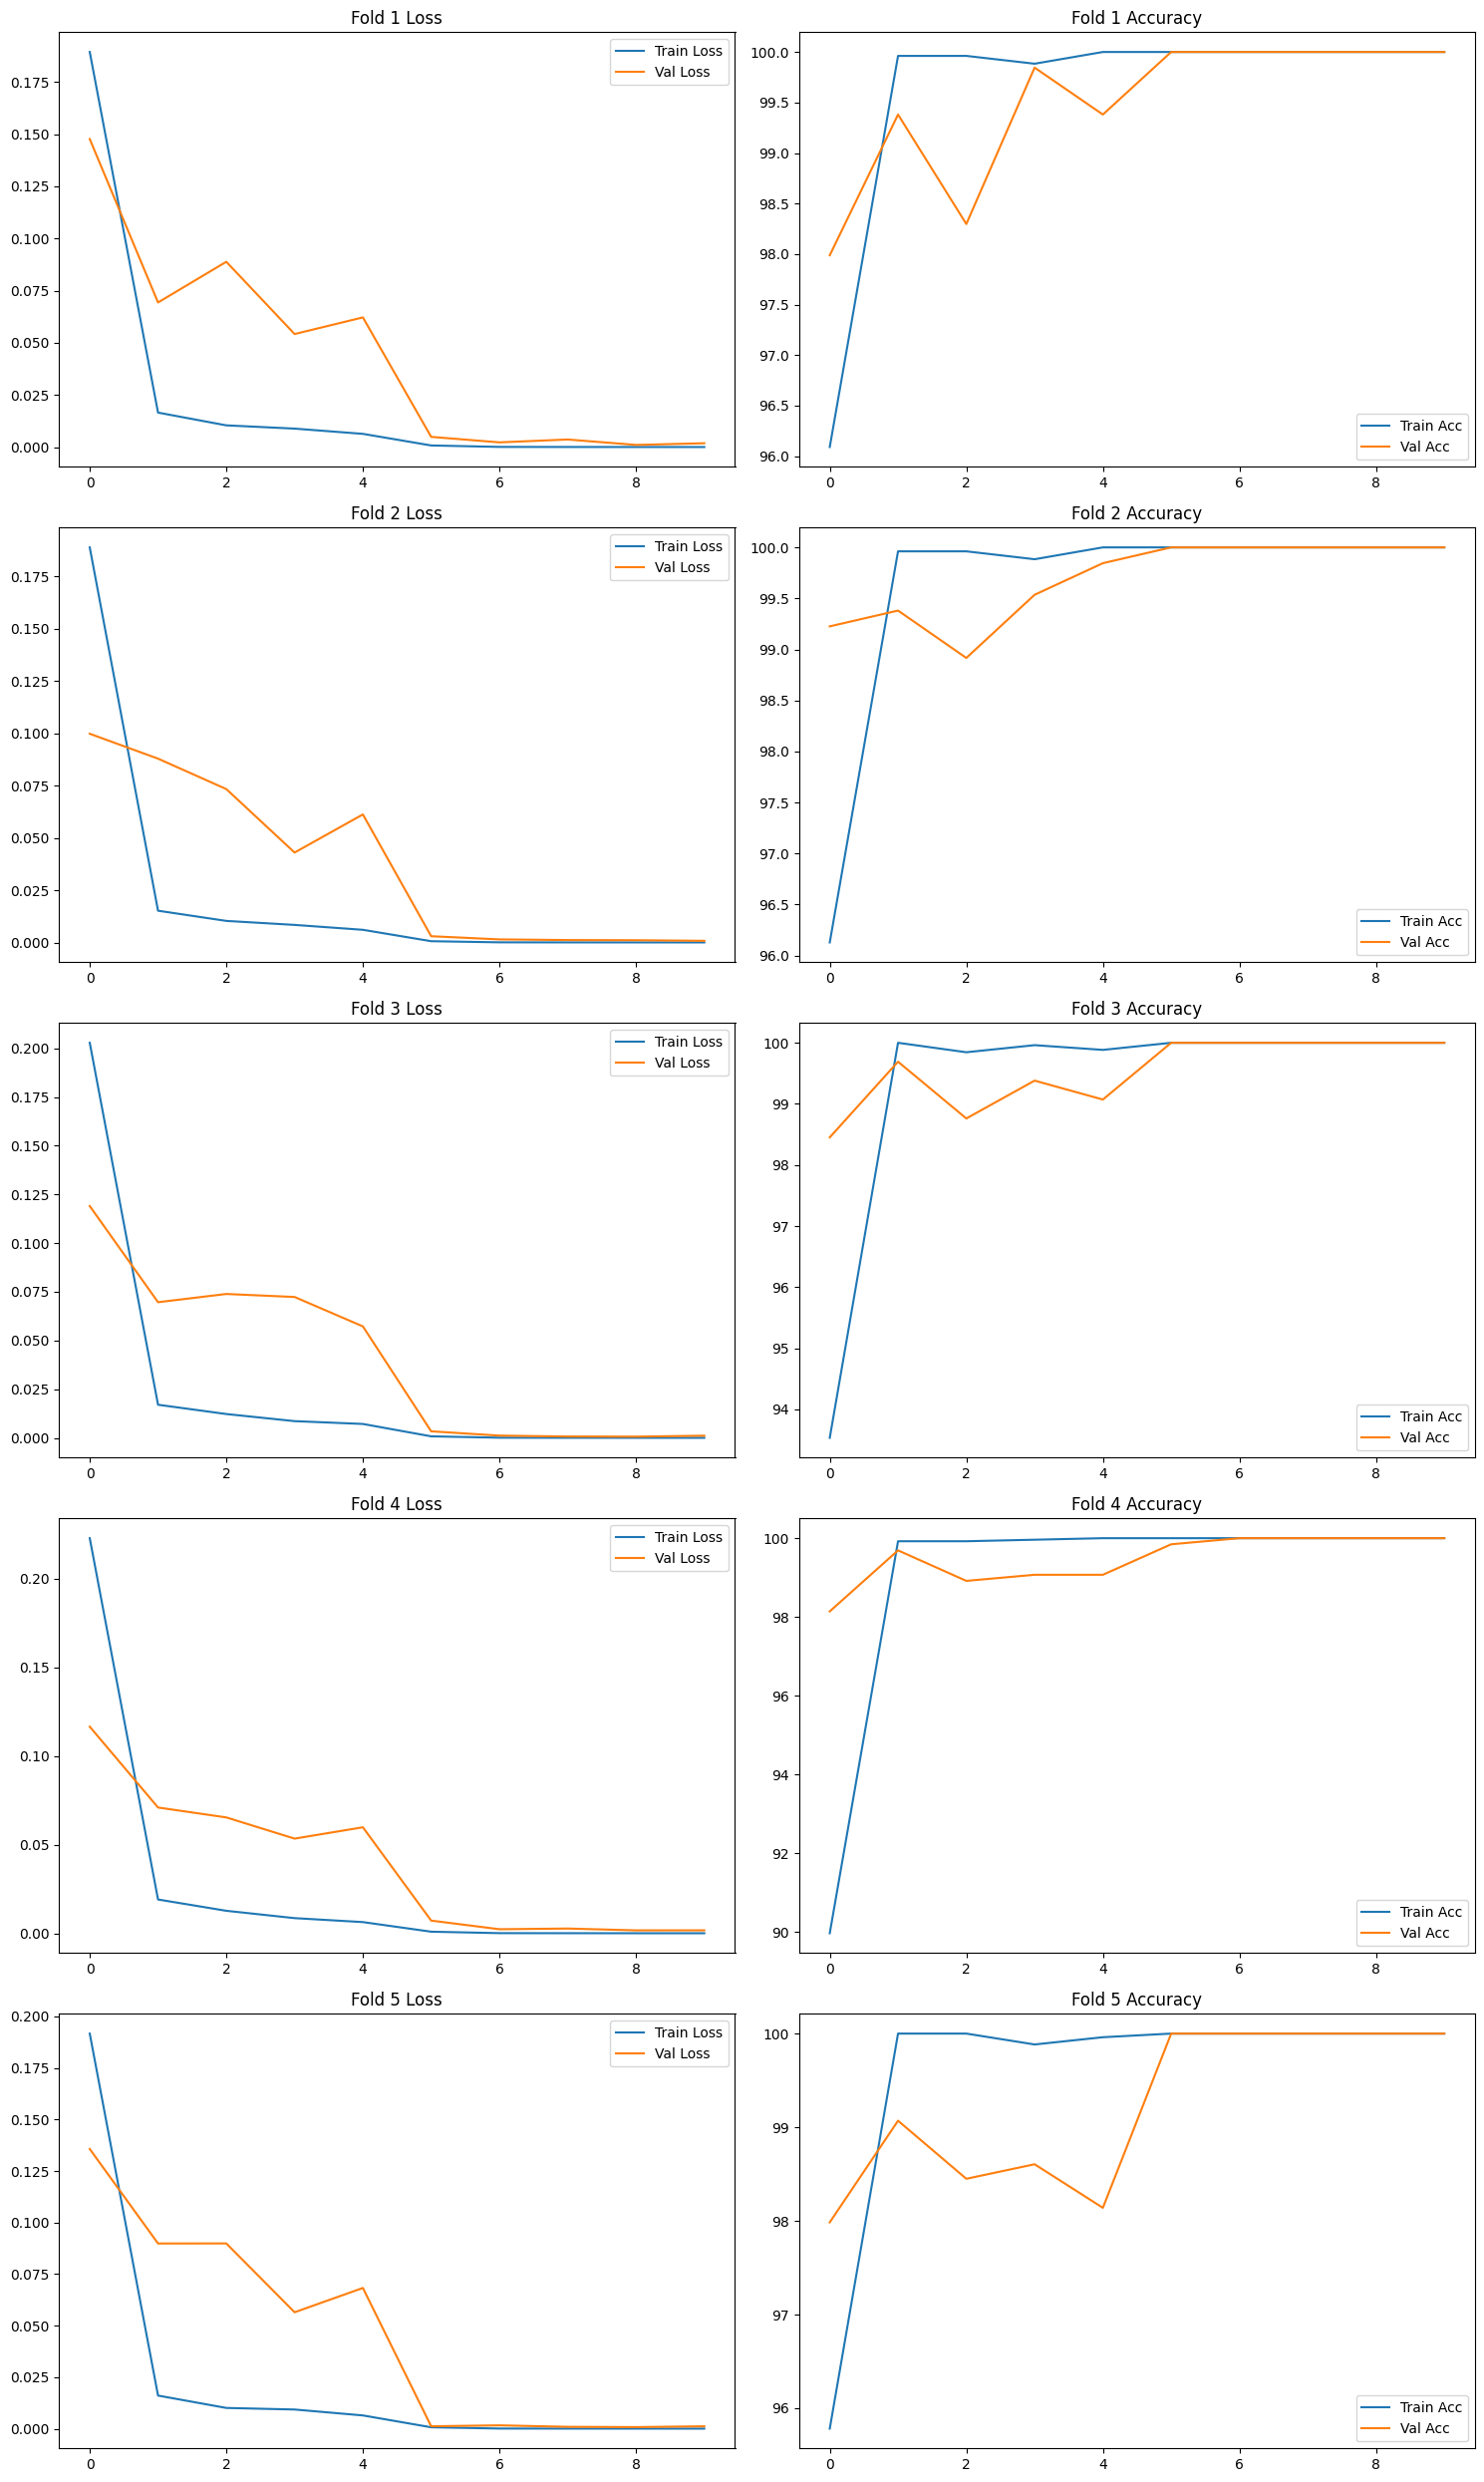

In [17]:
import matplotlib.pyplot as plt

if len(train_val_idx) > 0:
    skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
    fold_results = []
    models = []
    all_histories = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_idx, train_val_targets), 1):
        global_train_idx = [train_val_idx[i] for i in train_idx]
        global_val_idx = [train_val_idx[i] for i in val_idx]

        train_dataset = MapDataset(base_dataset, global_train_idx, transform=train_transforms)
        val_dataset = MapDataset(base_dataset, global_val_idx, transform=eval_transforms)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        best_fold_model, best_fold_acc, history = train_fold(fold, train_loader, val_loader, NUM_EPOCHS)
        fold_results.append(best_fold_acc)
        models.append(best_fold_model)
        all_histories.append(history)

    print(f"\n{'='*40}\nCross-Validation Complete")
    print(f"Average Validation Accuracy: {np.mean(fold_results):.2f}% (+/- {np.std(fold_results):.2f}%)")

    # Plotting results
    fig, axes = plt.subplots(K_FOLDS, 2, figsize=(15, 5 * K_FOLDS))
    for i, hist in enumerate(all_histories):
        # Loss plot
        axes[i, 0].plot(hist['train_loss'], label='Train Loss')
        axes[i, 0].plot(hist['val_loss'], label='Val Loss')
        axes[i, 0].set_title(f'Fold {i+1} Loss')
        axes[i, 0].legend()

        # Accuracy plot
        axes[i, 1].plot(hist['train_acc'], label='Train Acc')
        axes[i, 1].plot(hist['val_acc'], label='Val Acc')
        axes[i, 1].set_title(f'Fold {i+1} Accuracy')
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No data available to train.")

## Final Evaluation on Untouched Test Set

In [18]:
# Evaluate the best model across all folds on the untouched test set
# Alternately, we can do an ensemble prediction using all fold models. We will evaluate the best model here.

if len(train_val_idx) > 0 and test_loader:
    best_fold_idx = np.argmax(fold_results)
    best_model = models[best_fold_idx]

    print(f"Evaluating the best model (from Fold {best_fold_idx + 1}) on the untouched Test Set...")

    best_model.eval()
    test_correct = 0
    test_total = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = best_model(inputs)
            _, predicted = outputs.max(1)

            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    test_acc = 100. * test_correct / test_total
    print(f"\nUntouched Test Set Accuracy: {test_acc:.2f}%\n")

    print("Classification Report:")
    print(classification_report(all_targets, all_preds, target_names=base_dataset.classes))

    print("Confusion Matrix:")
    print(confusion_matrix(all_targets, all_preds))


Evaluating the best model (from Fold 1) on the untouched Test Set...

Untouched Test Set Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

    New_data       1.00      1.00      1.00       359

    accuracy                           1.00       359
   macro avg       1.00      1.00      1.00       359
weighted avg       1.00      1.00      1.00       359

Confusion Matrix:
[[359]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
